# Experiment No 3: Batch Normalization Analysis

### Reason for Experimentation
When we are building deep machine learning models to train on large datasets we hope that the large deepe model will be able to extract information from the training dataset. This does happen but it takes alot of time and iterations for it to reach a considerable trained state. The amount of time it takes to reach this state leads to the thought that training even larger model would not benefit as it will take even more time to reach its trained state. 

This is because in deep models with multiple layers of neurons even a small change in the input leads to large change in the downstream layers which means with every batch size the distribution of the training data changes which does not help the weights to reach the state which has the highest accuracy. 

To handle this Batch Normalization was introduced. This experiment is done in order to observe if adding **batch normalization** layers to a model allow for faster training as it stabilizes the distribution of the data.

To know more about batch normalization in detail you can have a look at the notebook `/notebooks/batch_normalization.ipynb`

### Experiment Design
1. The experiment will be carried out on the CIFAR 10 dataset.
2. The experiment setup is the same as the one presented in the **ResNet** paper.
3. 3 models will be trained on the dataset. 
   1. These models are inspired by ResNet architecture.
   2. For simplification residual connections will not be used as we want to observe the effect of batch normalization
   3. The three models will be an 20 layer model with no batch normalization layers, an 20 layer model with batch normalization layers and a 56 layer model with batch normalization layers.
4. The models will be trained for $32,000$ iterations.
5. The batch size will be same across all models which will be **256**.
   1.  For training we have $50,000$ images and since the batch size is **256** we would have ~391 iterations for one cycle of training data.
   2. $32,000$ iterations will be covered in ~**163** epochs.
6. The learning rate will start at **0.001** and will drop to **0.0001** and **0.0001** at 50% and 75% completetion rate.
7. Model comparison will be done on **error percentage** on both training and test set.

### Expected Result
The expectation is that the model trained with batch normalization layers reach lower error percentage in less number of iterations indicating that **batch normalization helps in faster convergence**.

**Note**:<br>
1. A model with 56 layers is being trained to also see whether a deeper model with batch normalization is able to out perform a smaller model when both of them are using batch normalization layers.
2. We have to perform kaiming initialization and be less aggressive while learning as the plain model will not be able to learn anything from the data without them therefore we change the learning rate to go from **0.1** -> **0.01** -> **0.001** to **0.001** -> **0.0001** -> **0.00001** and perform kaiming initialization of weights for all of the models
3. For the current experiment regarding the initialization process you only need to keep in mind that the initialization is a process to setup initial weights so that the models do not get impacted by vanishing or exploding gradients when we are going for deep models. To more about initializations you can have a look at `\notebooks\initialization.ipynb`

### Import libraries to be used througout the experiment

In [1]:
import json
import math
import torch
import pandas as pd
from typing import Self
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from pathlib import Path
from torch.optim import SGD
from torch.optim.lr_scheduler import MultiStepLR

from torchvision.transforms import v2
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

# RANDOM STATE FOR REPRODUCIBILITY
RANDOM_STATE = 42
# SETUP DEVICE
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

%matplotlib inline

### Result and dataset storage paths

In [2]:
current_dir = Path.cwd()

# Path to the folder where CIFAR 10 dataset will be downloaded
dataset_root_folder = current_dir.parent / 'datasets' / 'cifar10_dataset'

# Path to the file where the results of this experimentation will be stored
results_path = current_dir.parent / 'results' / '03_batch_normalization_analysis.json'

# Store the absolute path required for the dataset and result file
dataset_root_abs_path = dataset_root_folder.absolute()
result_abs_path = results_path.absolute()

### Classes to be used throughout the experiment

In [3]:
class Plain20(torch.nn.Module):
    """
    Class representing a CNN model to be trained on CIFAR 10 dataset inspired by ResNet architecture.

    This is an 18 layer model with no batch normalization layers 
    """

    def __init__(self, num_classes: int = 10) -> None:
        """
        Method to initialize an instance of :class: Plain20

        :param num_classes: Number of classes present in the dataset. Defaults to 10 for CIFAR 10

        :returns: Instance of :class: Plain20
        """

        super().__init__()
        # Input: (N, 3, 32, 32) -> Output: (N, 16, 32, 32) (Layer 1)
        self.conv_layer_1 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1, dilation=1, bias=False),
                                torch.nn.ReLU())
        # Input: (N, 16, 32, 32) -> Output: (N, 16, 32, 32) (Layer 2 and 7)
        self.conv_layer_2 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                )
        # Input: (N, 16, 32, 32) -> Output: (N, 32, 16, 16) (Layer 8 to 13)
        self.conv_layer_3 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1, stride=2, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                )
        # Input: (N, 32, 16, 16) -> Output: (N, 64, 8, 8) (Layer 14 to 19)
        self.conv_layer_4 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=2, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.ReLU(),
                                )

        # Input: (N, 64, 8, 8) -> Output: (N, 64, 1, 1)
        self.average_pooling_layer = torch.nn.AvgPool2d(kernel_size=8, stride=1, padding=0)

        # 20th layer
        self.classifer = torch.nn.Sequential(torch.nn.Flatten(),
                                             torch.nn.Linear(in_features=64, out_features=num_classes))
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate input tensor through Plain20 model

        :param X: Input tensor

        :returns: Result of forward propagation
        """

        X = self.conv_layer_1(X)
        X = self.conv_layer_2(X)
        X = self.conv_layer_3(X)
        X = self.conv_layer_4(X)
        X = self.average_pooling_layer(X)

        return self.classifer(X)


class BN20(torch.nn.Module):
    """
    Class representing a CNN model to be trained on CIFAR 10 dataset inspired by ResNet architecture.

    This is an 18 layer model with batch normalization layers 
    """

    def __init__(self, num_classes: int = 10) -> None:
        """
        Method to initialize an instance of :class: BN20

        :param num_classes: Number of classes present in the dataset. Defaults to 10 for CIFAR 10

        :returns: Instance of :class: BN20
        """

        super().__init__()
        # Input: (N, 3, 32, 32) -> Output: (N, 16, 32, 32) (Layer 1)
        self.conv_layer_1 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU())
        # Input: (N, 16, 32, 32) -> Output: (N, 16, 32, 32) (Layer 2 and 7)
        self.conv_layer_2 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                )
        # Input: (N, 16, 32, 32) -> Output: (N, 32, 16, 16) (Layer 8 to 13)
        self.conv_layer_3 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1, stride=2, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                )
        # Input: (N, 32, 16, 16) -> Output: (N, 64, 8, 8) (Layer 14 to 19)
        self.conv_layer_4 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=2, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                )

        # Input: (N, 64, 8, 8) -> Output: (N, 64, 1, 1)
        self.average_pooling_layer = torch.nn.AvgPool2d(kernel_size=8, stride=1, padding=0)

        # 20th layer
        self.classifer = torch.nn.Sequential(torch.nn.Flatten(),
                                             torch.nn.Linear(in_features=64, out_features=num_classes))
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate input tensor through BN20 model

        :param X: Input tensor

        :returns: Result of forward propagation
        """

        X = self.conv_layer_1(X)
        X = self.conv_layer_2(X)
        X = self.conv_layer_3(X)
        X = self.conv_layer_4(X)
        X = self.average_pooling_layer(X)

        return self.classifer(X)


class BN56(torch.nn.Module):
    """
    Class representing a CNN model to be trained on CIFAR 10 dataset inspired by ResNet architecture.

    This is an 56 layer model with batch normalization layers 
    """

    def __init__(self, num_classes: int = 10) -> None:
        """
        Method to initialize an instance of :class: BN56

        :param num_classes: Number of classes present in the dataset. Defaults to 10 for CIFAR 10

        :returns: Instance of :class: BN56
        """

        super().__init__()
        # Input: (N, 3, 32, 32) -> Output: (N, 16, 32, 32) (Layer 1)
        self.conv_layer_1 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, stride=1, padding=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU())
        # Input: (N, 16, 32, 32) -> Output: (N, 16, 32, 32) (Layer 2 and 19)
        self.conv_layer_2 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),                            
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),

                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=16, out_channels=16, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=16),
                                torch.nn.ReLU(),
                                )

        # Input: (N, 16, 32, 32) -> Output: (N, 32, 16, 16) (Layer 20 to 37)
        self.conv_layer_3 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1, stride=2, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),

                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=32),
                                torch.nn.ReLU())
        # Input: (N, 32, 16, 16) -> Output: (N, 64, 8, 8) (Layer 38 to 55)
        self.conv_layer_4 = torch.nn.Sequential(
                                torch.nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1, stride=2, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),

                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU(),
                                torch.nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1, stride=1, dilation=1, bias=False),
                                torch.nn.BatchNorm2d(num_features=64),
                                torch.nn.ReLU())

        # Input: (N, 64, 8, 8) -> Output: (N, 64, 1, 1)
        self.average_pooling_layer = torch.nn.AvgPool2d(kernel_size=8, stride=1, padding=0)

        # 56th layer
        self.classifer = torch.nn.Sequential(torch.nn.Flatten(),
                                             torch.nn.Linear(in_features=64, out_features=num_classes))
    
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        Method to propagate input tensor through BN56 model

        :param X: Input tensor

        :returns: Result of forward propagation
        """

        X = self.conv_layer_1(X)
        X = self.conv_layer_2(X)
        X = self.conv_layer_3(X)
        X = self.conv_layer_4(X)
        X = self.average_pooling_layer(X)

        return self.classifer(X)
    
def initialize_weights_kaiming(module):
    if isinstance(module, torch.nn.Conv2d):
        # Kaiming He initialization specifically designed for ReLU activation
        torch.nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
        if module.bias is not None:
            torch.nn.init.constant_(module.bias, 0)
    elif isinstance(module, torch.nn.Linear):
        # Standard initialization for the final fully connected layer
        torch.nn.init.normal_(module.weight, 0, 0.01)
        torch.nn.init.constant_(module.bias, 0)

### Experiment configuration

In [4]:
GAMMA = 0.1
NUM_CLASSES = 10
LEARNING_RATE = 0.01
WEIGHT_DECAY = 0.0001
TOTAL_ITERATIONS = 32000
ITERATION_COMPLETION_RATE_50 = int(round(TOTAL_ITERATIONS * 0.5, 0))
ITERATION_COMPLETION_RATE_75 = int(round(TOTAL_ITERATIONS * 0.75, 0))

TRAIN_BATCH_SIZE = 256
TEST_BATCH_SIZE = 1024

TRAINING_SAMPLES = 50000

ITERATIONS_PER_BATCH = int(round(TRAINING_SAMPLES / TRAIN_BATCH_SIZE, 0))
TOTAL_EPOCHS = int(round(TOTAL_ITERATIONS / ITERATIONS_PER_BATCH, 0))

EPOCH_COMPLETION_RATE_50 = int(round(ITERATION_COMPLETION_RATE_50 / ITERATIONS_PER_BATCH, 0))
EPOCH_COMPLETION_RATE_75 = int(round(ITERATION_COMPLETION_RATE_75 / ITERATIONS_PER_BATCH, 0))

loss_function = torch.nn.CrossEntropyLoss()
result_dict = {}

### Load Datasets

In [5]:
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)

# Transforms required to convert images into 3x32x32 normalized tensors
feature_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(dtype=torch.float32),
    v2.Normalize(mean=(0.491, 0.482, 0.446), std=(0.247, 0.243, 0.261))
])

# Convert class labels to one hot encoded labels
target_transforms = v2.Lambda(lambda x: torch.nn.functional.one_hot(torch.tensor(x), num_classes=NUM_CLASSES).float())


# Load CIFAR 10 dataset train and test (set `download` to True if you want to download it for the first time)
train_dataset = CIFAR10(root=dataset_root_abs_path,
                        train=True,
                        download=False,
                        transform=feature_transforms,
                        target_transform=target_transforms)

test_dataset = CIFAR10(root=dataset_root_abs_path,
                       train=False,
                       download=False,
                       transform=feature_transforms,
                       target_transform=target_transforms)

# Load the train and test datasets onto their train and test dataloaders
train_dataloader = DataLoader(dataset=train_dataset,
                              batch_size=TRAIN_BATCH_SIZE,
                              shuffle=True,
                              pin_memory=True)

# Using the below data loader for faster error calculation
train_dataloader_v2 = DataLoader(dataset=train_dataset,
                              batch_size=TEST_BATCH_SIZE,
                              shuffle=True,
                              pin_memory=True)

test_dataloader = DataLoader(dataset=test_dataset,
                              batch_size=TEST_BATCH_SIZE,
                              shuffle=False,
                              pin_memory=True)

/home/vaibhav/.local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### Train and Evaluate Plain20, BN20 and BN56 model on CIFAR 10

In [6]:
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)

plain_model = Plain20(num_classes=NUM_CLASSES)
bn20_model = BN20(num_classes=NUM_CLASSES)
bn56_model = BN56(num_classes=NUM_CLASSES)

plain_model = plain_model.to(DEVICE)
bn20_model = bn20_model.to(DEVICE)
bn56_model = bn56_model.to(DEVICE)

plain_model.apply(initialize_weights_kaiming)
bn20_model.apply(initialize_weights_kaiming)
bn56_model.apply(initialize_weights_kaiming)


plain_optimizer = SGD(plain_model.parameters(), lr=LEARNING_RATE, momentum=0.9)
bn20_optimizer = SGD(bn20_model.parameters(), lr=LEARNING_RATE, momentum=0.9)
bn56_optimizer = SGD(bn56_model.parameters(), lr=LEARNING_RATE, momentum=0.9)

plain_scheduler = MultiStepLR(optimizer=plain_optimizer, milestones=[EPOCH_COMPLETION_RATE_50, EPOCH_COMPLETION_RATE_75], gamma=0.1)
bn20_scheduler = MultiStepLR(optimizer=bn20_optimizer, milestones=[EPOCH_COMPLETION_RATE_50, EPOCH_COMPLETION_RATE_75], gamma=0.1)
bn56_scheduler = MultiStepLR(optimizer=bn56_optimizer, milestones=[EPOCH_COMPLETION_RATE_50, EPOCH_COMPLETION_RATE_75], gamma=0.1)

plain20_train_error_percentage_list = []
bn20_train_error_percentage_list = []
bn56_train_error_percentage_list = []

plain20_test_error_percentage_list = []
bn20_test_error_percentage_list = []
bn56_test_error_percentage_list = []

with tqdm(total=TOTAL_EPOCHS, desc="Experiment Life") as progress_bar:
    for epoch in range(TOTAL_EPOCHS):
        plain_model.train()
        bn20_model.train()
        bn56_model.train()

        for X, y in train_dataloader:
            X = X.to(DEVICE)
            y = y.to(DEVICE)

            plain_20_y_pred = plain_model(X)
            bn_20_y_pred = bn20_model(X)
            bn_56_y_pred = bn56_model(X)
    
            plain_20_loss = loss_function(plain_20_y_pred, y)
            bn_20_loss = loss_function(bn_20_y_pred, y)
            bn_56_loss = loss_function(bn_56_y_pred, y)

            plain_optimizer.zero_grad()
            bn20_optimizer.zero_grad()
            bn56_optimizer.zero_grad()

            plain_20_loss.backward()
            bn_20_loss.backward()
            bn_56_loss.backward()

            plain_optimizer.step()
            bn20_optimizer.step()
            bn56_optimizer.step()

        plain_model.eval()
        bn20_model.eval()
        bn56_model.eval()

        plain_20_train_error = 0
        bn_20_train_error = 0
        bn_56_train_error = 0
        total_train_samples = 0

        plain_20_test_error = 0
        bn_20_test_error = 0
        bn_56_test_error = 0
        total_test_samples = 0

        with torch.inference_mode():
            for X, y in train_dataloader_v2:
                X = X.to(DEVICE)
                y = y.to(DEVICE)

                plain_20_y_pred = plain_model(X)
                bn_20_y_pred = bn20_model(X)
                bn_56_y_pred = bn56_model(X)

                y_argmax = y.argmax(dim=1, keepdim=True)
                plain_20_y_pred_argmax = plain_20_y_pred.argmax(dim=1, keepdim=True)
                bn_20_y_pred_argmax = bn_20_y_pred.argmax(dim=1, keepdim=True)
                bn_56_y_pred_argmax = bn_56_y_pred.argmax(dim=1, keepdim=True)

                plain_20_batch_result = y_argmax != plain_20_y_pred_argmax
                bn_20_batch_result = y_argmax != bn_20_y_pred_argmax
                bn_56_batch_result = y_argmax != bn_56_y_pred_argmax

                plain_20_train_error += plain_20_batch_result.sum().item()
                bn_20_train_error += bn_20_batch_result.sum().item()
                bn_56_train_error += bn_56_batch_result.sum().item()

                total_train_samples += TEST_BATCH_SIZE
    
            for X, y in test_dataloader:
                X = X.to(DEVICE)
                y = y.to(DEVICE)

                plain_20_y_pred = plain_model(X)
                bn_20_y_pred = bn20_model(X)
                bn_56_y_pred = bn56_model(X)

                y_argmax = y.argmax(dim=1, keepdim=True)
                plain_20_y_pred_argmax = plain_20_y_pred.argmax(dim=1, keepdim=True)
                bn_20_y_pred_argmax = bn_20_y_pred.argmax(dim=1, keepdim=True)
                bn_56_y_pred_argmax = bn_56_y_pred.argmax(dim=1, keepdim=True)

                plain_20_batch_result = y_argmax != plain_20_y_pred_argmax
                bn_20_batch_result = y_argmax != bn_20_y_pred_argmax
                bn_56_batch_result = y_argmax != bn_56_y_pred_argmax

                plain_20_test_error += plain_20_batch_result.sum().item()
                bn_20_test_error += bn_20_batch_result.sum().item()
                bn_56_test_error += bn_56_batch_result.sum().item()

                total_test_samples += TEST_BATCH_SIZE
        
        plain20_train_error_percentage_list.append(round((plain_20_train_error / total_train_samples) * 100, 3))
        bn20_train_error_percentage_list.append(round((bn_20_train_error / total_train_samples) * 100, 3))
        bn56_train_error_percentage_list.append(round((bn_56_train_error / total_train_samples) * 100, 3))

        plain20_test_error_percentage_list.append(round((plain_20_test_error / total_test_samples) * 100, 3))
        bn20_test_error_percentage_list.append(round((bn_20_test_error / total_test_samples) * 100, 3))
        bn56_test_error_percentage_list.append(round((bn_56_test_error / total_test_samples) * 100, 3))

        plain_scheduler.step()
        bn20_scheduler.step()
        bn56_scheduler.step()

        progress_bar.update(1)

Experiment Life:   0%|          | 0/164 [00:00<?, ?it/s]

### Store result

In [7]:
final_result_dict = {
                        'Plain_20_Train': plain20_train_error_percentage_list,
                        'Plain_20_Test': plain20_test_error_percentage_list,
                        'BN_20_Train': bn20_train_error_percentage_list,
                        'BN_20_Test': bn20_test_error_percentage_list,
                        'BN_56_Train': bn56_train_error_percentage_list,
                        'BN_56_Test': bn56_test_error_percentage_list
                    }

with Path.open(result_abs_path, mode='w') as file:
    json.dump(final_result_dict, file)

### Plot Graphs

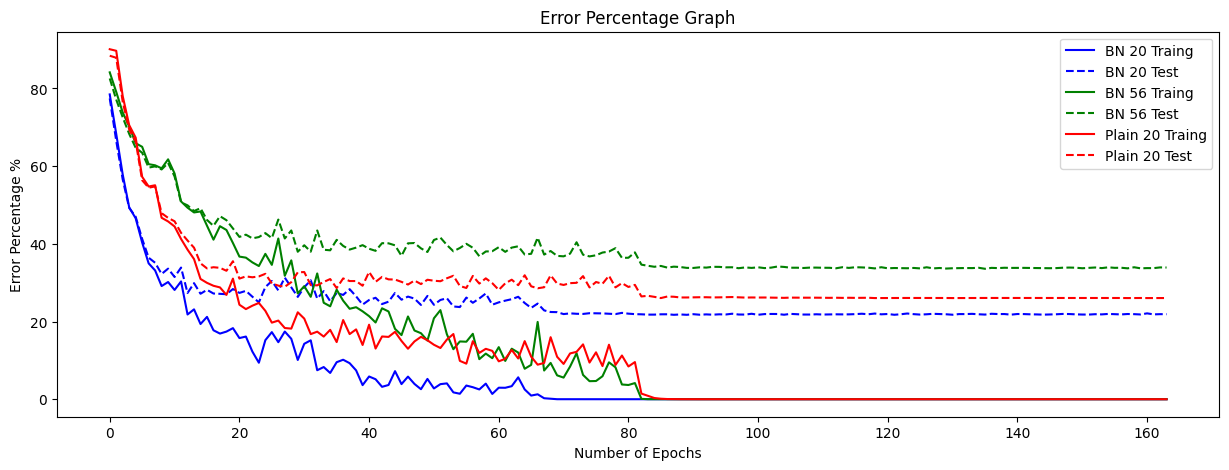

In [8]:
# Open stored results
with Path.open(result_abs_path, mode='r') as file:
    experiment_results = json.load(file)

df = pd.DataFrame(experiment_results)

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15,5))

axes.plot(list(range(TOTAL_EPOCHS)), df["BN_20_Train"], color='blue', label='BN 20 Traing')
axes.plot(list(range(TOTAL_EPOCHS)), df["BN_20_Test"], color='blue', label='BN 20 Test', ls='--')
axes.plot(list(range(TOTAL_EPOCHS)), df["BN_56_Train"], color='green', label='BN 56 Traing')
axes.plot(list(range(TOTAL_EPOCHS)), df["BN_56_Test"], color='green', label='BN 56 Test', ls='--')
axes.plot(list(range(TOTAL_EPOCHS)), df["Plain_20_Train"], color='red', label='Plain 20 Traing')
axes.plot(list(range(TOTAL_EPOCHS)), df["Plain_20_Test"], color='red', label='Plain 20 Test', ls='--')
axes.set_title("Error Percentage Graph")
axes.set_xlabel("Number of Epochs")
axes.set_ylabel("Error Percentage %")
plt.legend()

### Conclusion
The goal was to see how well does batch normalization help in learning from the data. Froom the experiment we can learn at three interesting things.
1. 20 layer model with batch normalization performed better than 20 layer model without batch normalization. model with batch normalization was able to reach the same accuracy that the plain model was able to achieve in less number of epochs (expected results).
2. In deep architecture we need to initialize our weights properly for plain models to even learn as we can see that we had performed kaiming initialization. This initialization was done because without it plain deep models cannot learn even if ReLU as the non linear activation function is used.
3. With the help of batch normalization we can go agressive and start off with a higher learning rate. In the experiment we started with 0.001 instead of 0.1 and decay the weights in steps. We had to start with 0.001 as plain models could not as the gradients would explode leading to weights to reach infinity or do not change at all.
4. We can see that larger deeper model like BN56 could not out perform a smaller BN20 model. This means batch normalization is not the solution to that helps deeper models learn better. This is solved using **Residual Connections**. (You can learn more about them from `\notebooks\residual_connections.ipynb`)
